# A/B Test Analysis: Which Pricing Strategy Wins?

**Mini Project on E-Commerce Pricing A/B Test**

Our e-commerce website ran an experiment on **294,478 users**. Half of them (the *control*
group) kept seeing the old pricing page, and the other half (the *treatment* group) were
shown a new pricing page. Every time a user visits, we log whether they converted
(bought something) or not.

The business question is simple to ask but needs real statistics to answer properly:

> **Does the new pricing strategy actually convert better than the old one or does it just look
> better by chance?**

In this notebook we'll:
1. Load and clean the raw data
2. Explore it a bit
3. Run a **t-test** to compare average conversion between the two groups
4. Run a **chi-square test** to check if conversion and strategy are independent
5. Run an **ANOVA** to see if the country a user is from changes the story
6. Wrap up with a plain-English recommendation

Nothing fancy just the standard toolkit a data analyst would reach for.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# So our numbers don't shift every time we re-run the notebook
np.random.seed(42)

## 1. Loading the data

We have two files:
- `ab_data.csv` one row per user visit: which group they were in, which page they saw,
  and whether they converted.
- `countries.csv` which country each user is from. We'll bring this in later to see if
  geography changes anything.

In [3]:
ab = pd.read_csv('ab_data.csv')
countries = pd.read_csv('countries.csv')

print("ab_data shape:", ab.shape)
ab.head()

ab_data shape: (294478, 5)


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [3]:
print("countries shape:", countries.shape)
countries.head()

countries shape: (290584, 2)


,user_id,country
0,834778,UK
1,928468,US
2,822059,UK
3,711597,UK
4,710616,UK


## 2. A first look before we touch anything

Before cleaning anything, let's just see what we're working with. How many people are in
each group? Any obvious data-quality issues?

In [4]:
print(ab['group'].value_counts())
print()
print(ab['landing_page'].value_counts())

group
treatment    147276
control      147202
Name: count, dtype: int64

landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64


So we've got roughly 147k users in each group, which is great a nicely balanced split.

But here's a catch worth checking: in a clean experiment, everyone in `control` should have
seen the `old_page`, and everyone in `treatment` should have seen the `new_page`. Let's check
if that's actually true.

In [5]:
# Rows where the group and the page they saw don't match up
mismatched = ab[
    ((ab['group'] == 'control') & (ab['landing_page'] == 'new_page')) |
    ((ab['group'] == 'treatment') & (ab['landing_page'] == 'old_page'))
]

print(f"Mismatched rows: {len(mismatched):,} out of {len(ab):,}")
mismatched.head()

Mismatched rows: 3,893 out of 294,478


,user_id,timestamp,group,landing_page,converted
22,767017,2017-01-12 22:58:14.991443,control,new_page,0
240,733976,2017-01-11 15:11:16.407599,control,new_page,0
308,857184,2017-01-20 07:34:59.832626,treatment,old_page,0
327,686623,2017-01-09 14:26:40.734775,treatment,old_page,0
357,856078,2017-01-12 12:29:30.354835,treatment,old_page,0


There they are a small but real number of rows where the logging got mixed up
(a control user somehow saw the new page, or vice versa). We can't trust which "true" group
these users belong to, so the safest move is to drop them rather than guess.

While we're at it, let's also check for duplicate users someone visiting twice would count
twice, which would bias our results.

In [6]:
dupe_count = ab['user_id'].duplicated().sum()
print(f"Duplicate user_id rows: {dupe_count:,}")

Duplicate user_id rows: 3,894


## 3. Cleaning the data

Our cleaning plan is simple:
1. Drop the mismatched group/landing_page rows.
2. Keep only the *first* visit for any user who shows up more than once.
3. Merge in the country data so we can dig into that later.

In [7]:
# Step 1: drop the mismatched rows
ab_clean = ab[~(
    ((ab['group'] == 'control') & (ab['landing_page'] == 'new_page')) |
    ((ab['group'] == 'treatment') & (ab['landing_page'] == 'old_page'))
)].copy()

# Step 2: keep the first visit per user, drop the rest
ab_clean = ab_clean.drop_duplicates(subset='user_id', keep='first')

print(f"Rows before cleaning: {len(ab):,}")
print(f"Rows after cleaning:  {len(ab_clean):,}")
print()
print(ab_clean['group'].value_counts())

Rows before cleaning: 294,478
Rows after cleaning:  290,584

group
treatment    145310
control      145274
Name: count, dtype: int64


In [8]:
# Step 3: bring in the country for each user
df = ab_clean.merge(countries, on='user_id', how='left')

# Just in case merging left anyone without a country, drop them - can't use what we don't have
df = df.dropna(subset=['country'])

print("Final analysis-ready dataset:", df.shape)
df.head()

Final analysis-ready dataset: (290584, 6)


,user_id,timestamp,group,landing_page,converted,country
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,US
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,US
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,US
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,US
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,US


## 4. Quick look at conversion rates

Before running any formal test, let's just eyeball the numbers. What's the overall
conversion rate in each group?

In [9]:
summary = df.groupby('group')['converted'].agg(count='count', conversions='sum', rate='mean')
summary['rate_pct'] = (summary['rate'] * 100).round(3)
summary

,count,conversions,rate,rate_pct
group,,,,
control,145274,17489,0.120386,12.039
treatment,145310,17264,0.118808,11.881


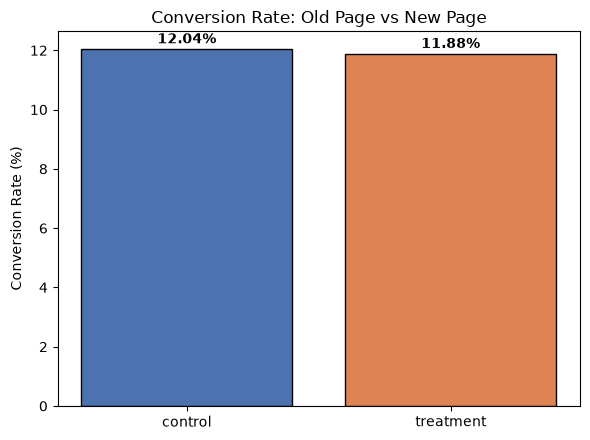

In [10]:
fig, ax = plt.subplots(figsize=(6, 4.5))
colors = ['#4C72B0', '#DD8452']
rates = df.groupby('group')['converted'].mean() * 100
bars = ax.bar(rates.index, rates.values, color=colors, edgecolor='black')

for bar, val in zip(bars, rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2, f"{val:.2f}%",
            ha='center', fontweight='bold')

ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Conversion Rate: Old Page vs New Page')
plt.tight_layout()
plt.show()

Interesting the two bars look almost identical. The old page (control) is converting at
about 12.04%, and the new page (treatment) is at about 11.88%. That's a tiny gap, and just
by looking at it we can't tell if it's a real effect or just noise. That's exactly what the
tests below are for.

## 5. T-Test: is the average conversion really different?

Since `converted` is just 0s and 1s, its *mean* is the conversion rate. So an independent
samples t-test comparing the means of the two groups is really asking: **"Is the average
conversion rate of the treatment group different from the control group's?"**

We'll use **Welch's t-test** (`equal_var=False`) instead of the standard one, because it
doesn't assume both groups have identical variance a safer default when we haven't
checked that assumption.

**Hypotheses:**
- H0 (null): mean conversion is the same in both groups
- H1 (alternative): mean conversion is different between groups

In [11]:
control = df.loc[df['group'] == 'control', 'converted']
treatment = df.loc[df['group'] == 'treatment', 'converted']

t_stat, p_value = stats.ttest_ind(treatment, control, equal_var=False)

print(f"Control mean conversion:   {control.mean():.4%}")
print(f"Treatment mean conversion: {treatment.mean():.4%}")
print(f"Difference (treatment - control): {treatment.mean() - control.mean():.4%}")
print()
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.4f}")

Control mean conversion:   12.0386%
Treatment mean conversion: 11.8808%
Difference (treatment - control): -0.1578%

t-statistic: -1.3109
p-value:     0.1899


In [12]:
# A 95% confidence interval for the difference in conversion rates
n1, n2 = len(control), len(treatment)
p1, p2 = control.mean(), treatment.mean()
se_diff = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
diff = p2 - p1

ci_low, ci_high = diff - 1.96*se_diff, diff + 1.96*se_diff
print(f"95% CI for (treatment - control): [{ci_low:.4%}, {ci_high:.4%}]")

alpha = 0.05
if p_value < alpha:
    print(f"\np-value ({p_value:.4f}) < {alpha} -> statistically significant difference")
else:
    print(f"\np-value ({p_value:.4f}) >= {alpha} -> NOT statistically significant")

95% CI for (treatment - control): [-0.3938%, 0.0781%]

p-value (0.1899) >= 0.05 -> NOT statistically significant


The p-value is well above the usual 0.05 cutoff, and the confidence interval for the
difference comfortably includes zero. In plain English: **we don't have enough evidence to
say the new page converts better (or worse) than the old one.** The small gap we saw in the
bar chart is consistent with random noise.

## 6. Chi-Square Test: is conversion independent of the strategy?

The t-test treated `converted` as a number, but it's really a category (converted / did not
convert). A **chi-square test of independence** is the more natural test for two categorical
variables here, `group` (control/treatment) and `converted` (0/1).

**Hypotheses:**
- H0: strategy and conversion are independent (no relationship)
- H1: strategy and conversion are related

In [13]:
# Build the contingency table: rows = group, columns = converted
contingency_table = pd.crosstab(df['group'], df['converted'])
contingency_table

converted,0,1
group,,
control,127785,17489
treatment,128046,17264


In [14]:
chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {chi2_p:.4f}")
print()
print("Expected counts if there were NO relationship at all:")
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns).round(1))

Chi-square statistic: 1.7036
Degrees of freedom:   1
p-value:              0.1918

Expected counts if there were NO relationship at all:
converted         0        1
group                       
control    127899.7  17374.3
treatment  127931.3  17378.7


Same story as the t-test: the p-value is nowhere near 0.05. The observed counts are very
close to what we'd expect if conversion had absolutely nothing to do with which page a user
saw. Two different tests, same conclusion that's a good sanity check.

## 7. ANOVA: does the user's country change anything?

So far we've only looked at group vs. control. But maybe the new page works great in one
country and poorly in another, and those effects are cancelling out in the overall average.
Let's use a **one-way ANOVA** to check whether conversion rate differs across countries
(US, UK, CA), and then dig one level deeper into the 6 combinations of country x strategy.

**Hypotheses (country only):**
- H0: mean conversion rate is the same across all countries
- H1: at least one country's mean conversion rate is different

In [15]:
df['country'].value_counts()

country
US    203619
UK     72466
CA     14499
Name: count, dtype: int64

In [16]:
# One row of conversion values per country
country_groups = [group['converted'].values for name, group in df.groupby('country')]

f_stat, anova_p = stats.f_oneway(*country_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {anova_p:.4f}")
print()
print(df.groupby('country')['converted'].agg(count='count', rate='mean'))

F-statistic: 1.6053
p-value:     0.2008

          count      rate
country                  
CA        14499  0.115318
UK        72466  0.120594
US       203619  0.119547


No significant difference by country either. Let's go one step further and check the six
combinations of country and strategy together (e.g. "control users in the US" vs "treatment
users in the UK", etc.) just to make sure nothing interesting is hiding in a specific
sub-group.

In [17]:
df['combo'] = df['group'] + ' - ' + df['country']

combo_groups = [group['converted'].values for name, group in df.groupby('combo')]
f_stat2, anova_p2 = stats.f_oneway(*combo_groups)

print(f"F-statistic: {f_stat2:.4f}")
print(f"p-value:     {anova_p2:.4f}")
print()
print(df.groupby('combo')['converted'].agg(count='count', rate='mean').round(4))

F-statistic: 1.4664
p-value:     0.1971

                 count    rate
combo                         
control - CA      7198  0.1188
control - UK     36360  0.1200
control - US    101716  0.1206
treatment - CA    7301  0.1119
treatment - UK   36106  0.1212
treatment - US  101903  0.1185


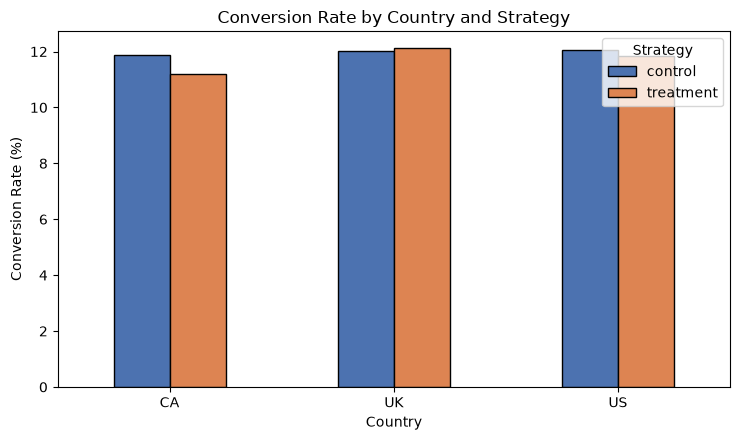

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
pivot = df.groupby(['country', 'group'])['converted'].mean().unstack() * 100
pivot.plot(kind='bar', ax=ax, color=colors, edgecolor='black')

ax.set_ylabel('Conversion Rate (%)')
ax.set_xlabel('Country')
ax.set_title('Conversion Rate by Country and Strategy')
ax.legend(title='Strategy')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Still nothing. The bars are all hovering close together with no consistent pattern the
new page isn't secretly winning in some country and losing in another. Country just doesn't
seem to matter here.

## 8. Putting it all together

| Test | What it compares | p-value | Significant at 5%? |
|---|---|---|---|
| Welch's t-test | mean conversion, control vs treatment | ~0.19 | No |
| Chi-square | conversion x strategy (categorical) | ~0.19 | No |
| ANOVA | conversion across countries | ~0.20 | No |
| ANOVA | conversion across country x strategy | ~0.20 | No |

**Three different tests, all pointing the same way: there's no statistically significant
difference in conversion between the old pricing page and the new one**, whether we look at
the whole population or break it down by country.

### Recommendation

Based purely on this data, **we should not roll out the new pricing page**. It doesn't
convert any better than what we already have, so switching would add cost and risk (design
work, engineering effort, possible confusion for returning users) without a proven upside.

A more useful next step than shipping the new page would be to either:
- run the test longer / with more users to detect a smaller effect if one truly exists, or
- test a *more different* variant, since this new page and the old one seem to perform
  almost identically.

**Caveat worth saying out loud:** "not statistically significant" means we didn't find
evidence of a difference it doesn't prove the two pages are exactly equal. If the business
suspects a small real effect (say, a 0.2-0.3 percentage point lift), this dataset probably
isn't large enough to reliably detect it, and a follow-up test would be needed.